# Demo data generation 1 for all

In this notebook, there is a simple example of how to generate a list of measures for different states of the engine, but with the same context for all states (1 list of context for all states).

In [8]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
# Standard imports
import matplotlib.pyplot as plt
import numpy as np

# Available of sensors
from odsmr.sensors import HPC_Tout, HP_Nmech, HPC_Tin, LPT_Tin, Fuel_flow, HPC_Pout_st, LP_Nmech
# Available flight conditions
from odsmr.context import  FlightCondDeckSMR, ContextDeckSMR
from odsmr.predefined_flight_conditions import Cruise_DeckSMR, Takeoff_DeckSMR, Climb1_DeckSMR, Climb2_DeckSMR
# Basic generation function
from odsmr.generation_functions import decksmr_1forall
from odsmr.helpers import sample_from_bounds, dict_to_array, extract_info
from odsmr.constants import ROOT_OPENDECK, STATE_LABELS, STATE_BOUNDS, FLIGHT_CONDITIONS_BOUNDS, FlightPhaseType



# How to run a simulation:
We will define a list of context, a list of health states, a list of sensors, and run the simulation "1forall", menianing that we obtain the value of the sensors knowning the context and the health states, same list of context for all the health states. 

In [10]:
# We define a list of sensors, which will never change:
list_sensors = [HPC_Tout(),
                HP_Nmech(),
                HPC_Tin(),
                LPT_Tin(),
                Fuel_flow(),
                HPC_Pout_st(),
                LP_Nmech()]

## Example 1: 1 predefined context, 1 health state

In [11]:
# Define a list of 1 predefined context:
list_context = [Cruise_DeckSMR]

# Define a list of one health state, for example a perfectly healthy engine:
list_of_state_values = [np.zeros(10)]

# Run the engine simulation
all_info_df = decksmr_1forall(list_state_value=list_of_state_values,
                        list_context=list_context,
                        list_sensors=list_sensors, sim_root=ROOT_OPENDECK)

print(all_info_df.shape)
# Dataframe containts the values of the sensors for one health state at the asked context
all_info_df.head()

(1, 24)


,HPC_Tout,HP_Nmech,HPC_Tin,LPT_Tin,Fuel_flow,HPC_Pout_st,LP_Nmech,context_name,phase_type,DTAMB,...,deg_CmpBst_s_mapEff_in,deg_CmpBst_s_mapWc_in,deg_CmpFan_s_mapEff_in,deg_CmpFan_s_mapWc_in,deg_CmpH_s_mapEff_in,deg_CmpH_s_mapWc_in,deg_TrbH_s_mapEff_in,deg_TrbH_s_mapWc_in,deg_TrbL_s_mapEff_in,deg_TrbL_s_mapWc_in
0,800.236664,19460.3405,335.952185,1121.022,0.372291,1379396.04,3958.61807,Cruise_DeckSMR,CR,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
# We can extract measurements:
measurements = extract_info(all_info_df, list_variables_name=[s.name for s in list_sensors], context_name=True, phase_type=False, flight_conditions=False)
measurements.head()

,HPC_Tout,HP_Nmech,HPC_Tin,LPT_Tin,Fuel_flow,HPC_Pout_st,LP_Nmech,context_name
0,800.236664,19460.3405,335.952185,1121.022,0.372291,1379396.04,3958.61807,Cruise_DeckSMR


In [13]:
# Or extract states values:
states = extract_info(all_info_df, list_variables_name=STATE_LABELS, context_name=True, phase_type=False, flight_conditions=False)
states.head()

,deg_CmpBst_s_mapEff_in,deg_CmpBst_s_mapWc_in,deg_CmpFan_s_mapEff_in,deg_CmpFan_s_mapWc_in,deg_CmpH_s_mapEff_in,deg_CmpH_s_mapWc_in,deg_TrbH_s_mapEff_in,deg_TrbH_s_mapWc_in,deg_TrbL_s_mapEff_in,deg_TrbL_s_mapWc_in,context_name
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cruise_DeckSMR


## Example 2: 1 predefined context, 2 health states

In [14]:
# Define a list of 1 predefined context:
list_context = [Cruise_DeckSMR]

# Define a list of *two* health states, for example a perfectly new engine and a random one:
list_of_state_values = [np.zeros(10), dict_to_array(sample_from_bounds(STATE_BOUNDS))]

# Run the engine simulation
all_info_df = decksmr_1forall(list_state_value=list_of_state_values,
                        list_context=list_context,
                        list_sensors=list_sensors, sim_root=ROOT_OPENDECK)
print(all_info_df.shape)
# Dataframe containts the values of the sensors for two health states at the asked context
all_info_df.head()


(2, 24)


,HPC_Tout,HP_Nmech,HPC_Tin,LPT_Tin,Fuel_flow,HPC_Pout_st,LP_Nmech,context_name,phase_type,DTAMB,...,deg_CmpBst_s_mapEff_in,deg_CmpBst_s_mapWc_in,deg_CmpFan_s_mapEff_in,deg_CmpFan_s_mapWc_in,deg_CmpH_s_mapEff_in,deg_CmpH_s_mapWc_in,deg_TrbH_s_mapEff_in,deg_TrbH_s_mapWc_in,deg_TrbL_s_mapEff_in,deg_TrbL_s_mapWc_in
0,800.236664,19460.3405,335.952185,1121.02200,0.372291,1379396.04,3958.61807,Cruise_DeckSMR,CR,10.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
1,795.044660,19351.1608,338.887929,1219.29195,0.404777,1323157.64,3896.86700,Cruise_DeckSMR,CR,10.0,...,-0.047572,-0.000559,-0.022675,0.006122,-0.005026,-0.032061,-0.048422,0.02628,-0.039797,-0.000615


## Example 3: 2 predefined contexts, 1 health state

In [15]:
# Define a list of 2 predefined context:
list_context = [Cruise_DeckSMR, Takeoff_DeckSMR]

# Define a list of one health state, for example a perfectly healthy engine:
list_of_state_values = [np.zeros(10)]
# Run the engine simulation
all_info_df = decksmr_1forall(list_state_value=list_of_state_values,
                        list_context=list_context,
                        list_sensors=list_sensors, sim_root=ROOT_OPENDECK)
print(all_info_df.shape)
# Dataframe containts the values of the sensors for one health state at the asked contexts
all_info_df.head()


(2, 24)


,HPC_Tout,HP_Nmech,HPC_Tin,LPT_Tin,Fuel_flow,HPC_Pout_st,LP_Nmech,context_name,phase_type,DTAMB,...,deg_CmpBst_s_mapEff_in,deg_CmpBst_s_mapWc_in,deg_CmpFan_s_mapEff_in,deg_CmpFan_s_mapWc_in,deg_CmpH_s_mapEff_in,deg_CmpH_s_mapWc_in,deg_TrbH_s_mapEff_in,deg_TrbH_s_mapWc_in,deg_TrbL_s_mapEff_in,deg_TrbL_s_mapWc_in
0,800.236664,19460.3405,335.952185,1121.02200,0.372291,1379396.04,3958.61807,Cruise_DeckSMR,CR,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,893.850732,20128.5920,386.363030,1262.31672,1.029476,3540138.36,4030.72625,Takeoff_DeckSMR,MTO,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Example 4: 1 predefined context, 1 random context, 1 health state

In [16]:
# Define a list of 1 predefined context and one random context:
fc = sample_from_bounds(FLIGHT_CONDITIONS_BOUNDS[FlightPhaseType.TAKEOFF])
phase_type = FlightPhaseType.TAKEOFF.value
random_takeoff_context = ContextDeckSMR(
                    name="Sampled_"+phase_type+"_DECKSMR",
                    flight_condition=FlightCondDeckSMR(
                        DTAMB=fc["DTAMB"],
                        ALT=fc["ALT"], 
                        MACH=fc["MACH"],  
                        COMMAND=fc["COMMAND"],
                        PHASE_TYPE=phase_type
                    )
                )
list_context = [Cruise_DeckSMR, random_takeoff_context]

# Define a list of one health state, for example a perfectly healthy engine:
list_of_state_values = [np.zeros(10)]
# Run the engine simulation
all_info_df = decksmr_1forall(list_state_value=list_of_state_values,
                        list_context=list_context,
                        list_sensors=list_sensors, sim_root=ROOT_OPENDECK)
print(all_info_df.shape)
# Dataframe containts the values of the sensors for one health state at the asked contexts
all_info_df.head()


(2, 24)


,HPC_Tout,HP_Nmech,HPC_Tin,LPT_Tin,Fuel_flow,HPC_Pout_st,LP_Nmech,context_name,phase_type,DTAMB,...,deg_CmpBst_s_mapEff_in,deg_CmpBst_s_mapWc_in,deg_CmpFan_s_mapEff_in,deg_CmpFan_s_mapWc_in,deg_CmpH_s_mapEff_in,deg_CmpH_s_mapWc_in,deg_TrbH_s_mapEff_in,deg_TrbH_s_mapWc_in,deg_TrbL_s_mapEff_in,deg_TrbL_s_mapWc_in
0,800.236664,19460.3405,335.952185,1121.02200,0.372291,1379396.04,3958.61807,Cruise_DeckSMR,CR,10.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,893.777718,20132.2877,386.227503,1262.28498,1.027813,3534110.45,4031.63355,Sampled_MTO_DECKSMR,MTO,14.118299,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Example 5: 4 predefined context, 5 health states

In [17]:
# Here we defined a list of 4 contexts and a list of 5 health states:
list_context = [Cruise_DeckSMR, Takeoff_DeckSMR, Climb1_DeckSMR, Climb2_DeckSMR]
list_of_state_values = [np.zeros(10),
                    -np.ones(10)*0.001,
                    -np.ones(10)*0.002,
                    -np.ones(10)*0.01,
                    -np.array([2, 2, 1, 1, 3, 3, 2, 1, 1, 4])*0.001]

all_info_df = decksmr_1forall(list_state_value=list_of_state_values,
                        list_context=list_context,
                        list_sensors=list_sensors, sim_root=ROOT_OPENDECK)

print(all_info_df.shape)
# Dataframe containts the values of the sensors for the 5 health states at the asked contexts
all_info_df.head()


(20, 24)


,HPC_Tout,HP_Nmech,HPC_Tin,LPT_Tin,Fuel_flow,HPC_Pout_st,LP_Nmech,context_name,phase_type,DTAMB,...,deg_CmpBst_s_mapEff_in,deg_CmpBst_s_mapWc_in,deg_CmpFan_s_mapEff_in,deg_CmpFan_s_mapWc_in,deg_CmpH_s_mapEff_in,deg_CmpH_s_mapWc_in,deg_TrbH_s_mapEff_in,deg_TrbH_s_mapWc_in,deg_TrbL_s_mapEff_in,deg_TrbL_s_mapWc_in
0,800.236664,19460.3405,335.952185,1121.02200,0.372291,1379396.04,3958.61807,Cruise_DeckSMR,CR,10.0,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,800.378911,19442.2897,336.161428,1123.12190,0.373045,1380781.59,3962.22446,Cruise_DeckSMR,CR,10.0,...,-0.001,-0.001,-0.001,-0.001,-0.001,-0.001,-0.001,-0.001,-0.001,-0.001
2,800.530533,19424.1882,336.375114,1125.25318,0.373805,1382155.54,3965.84248,Cruise_DeckSMR,CR,10.0,...,-0.002,-0.002,-0.002,-0.002,-0.002,-0.002,-0.002,-0.002,-0.002,-0.002
3,802.121047,19251.1819,338.218754,1144.39261,0.380290,1391896.79,3995.43795,Cruise_DeckSMR,CR,10.0,...,-0.010,-0.010,-0.010,-0.010,-0.010,-0.010,-0.010,-0.010,-0.010,-0.010
4,799.461001,19394.6962,336.342321,1125.62856,0.373224,1377564.64,3962.91960,Cruise_DeckSMR,CR,10.0,...,-0.002,-0.002,-0.001,-0.001,-0.003,-0.003,-0.002,-0.001,-0.001,-0.004


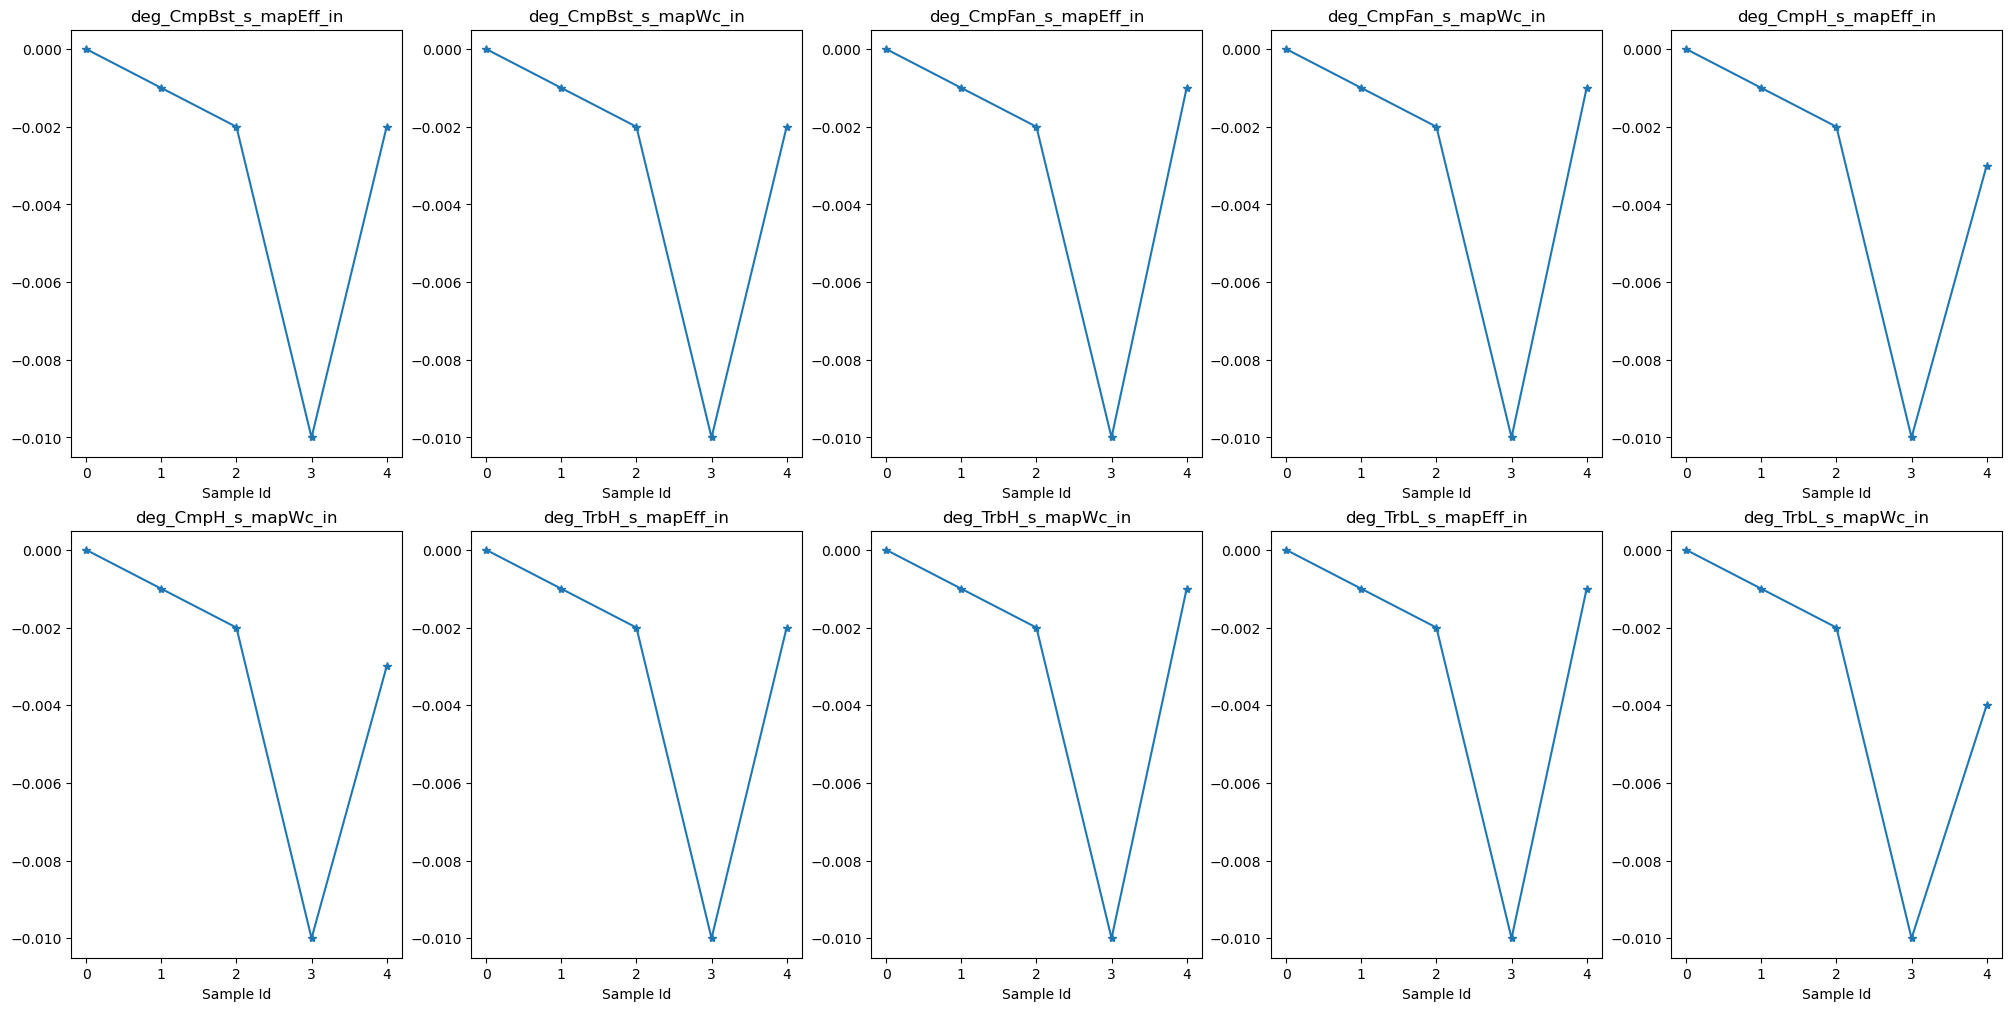

In [18]:
plt.figure(figsize=(20, 10), layout="constrained")
id_plot = 1
for id_state in range(10):
     plt.subplot(2, 5, id_plot)
     id_plot += 1
     plt.plot(np.array(list_of_state_values)[:, id_state], '-*')
     plt.title(STATE_LABELS[id_state])
     plt.xlabel('Sample Id')


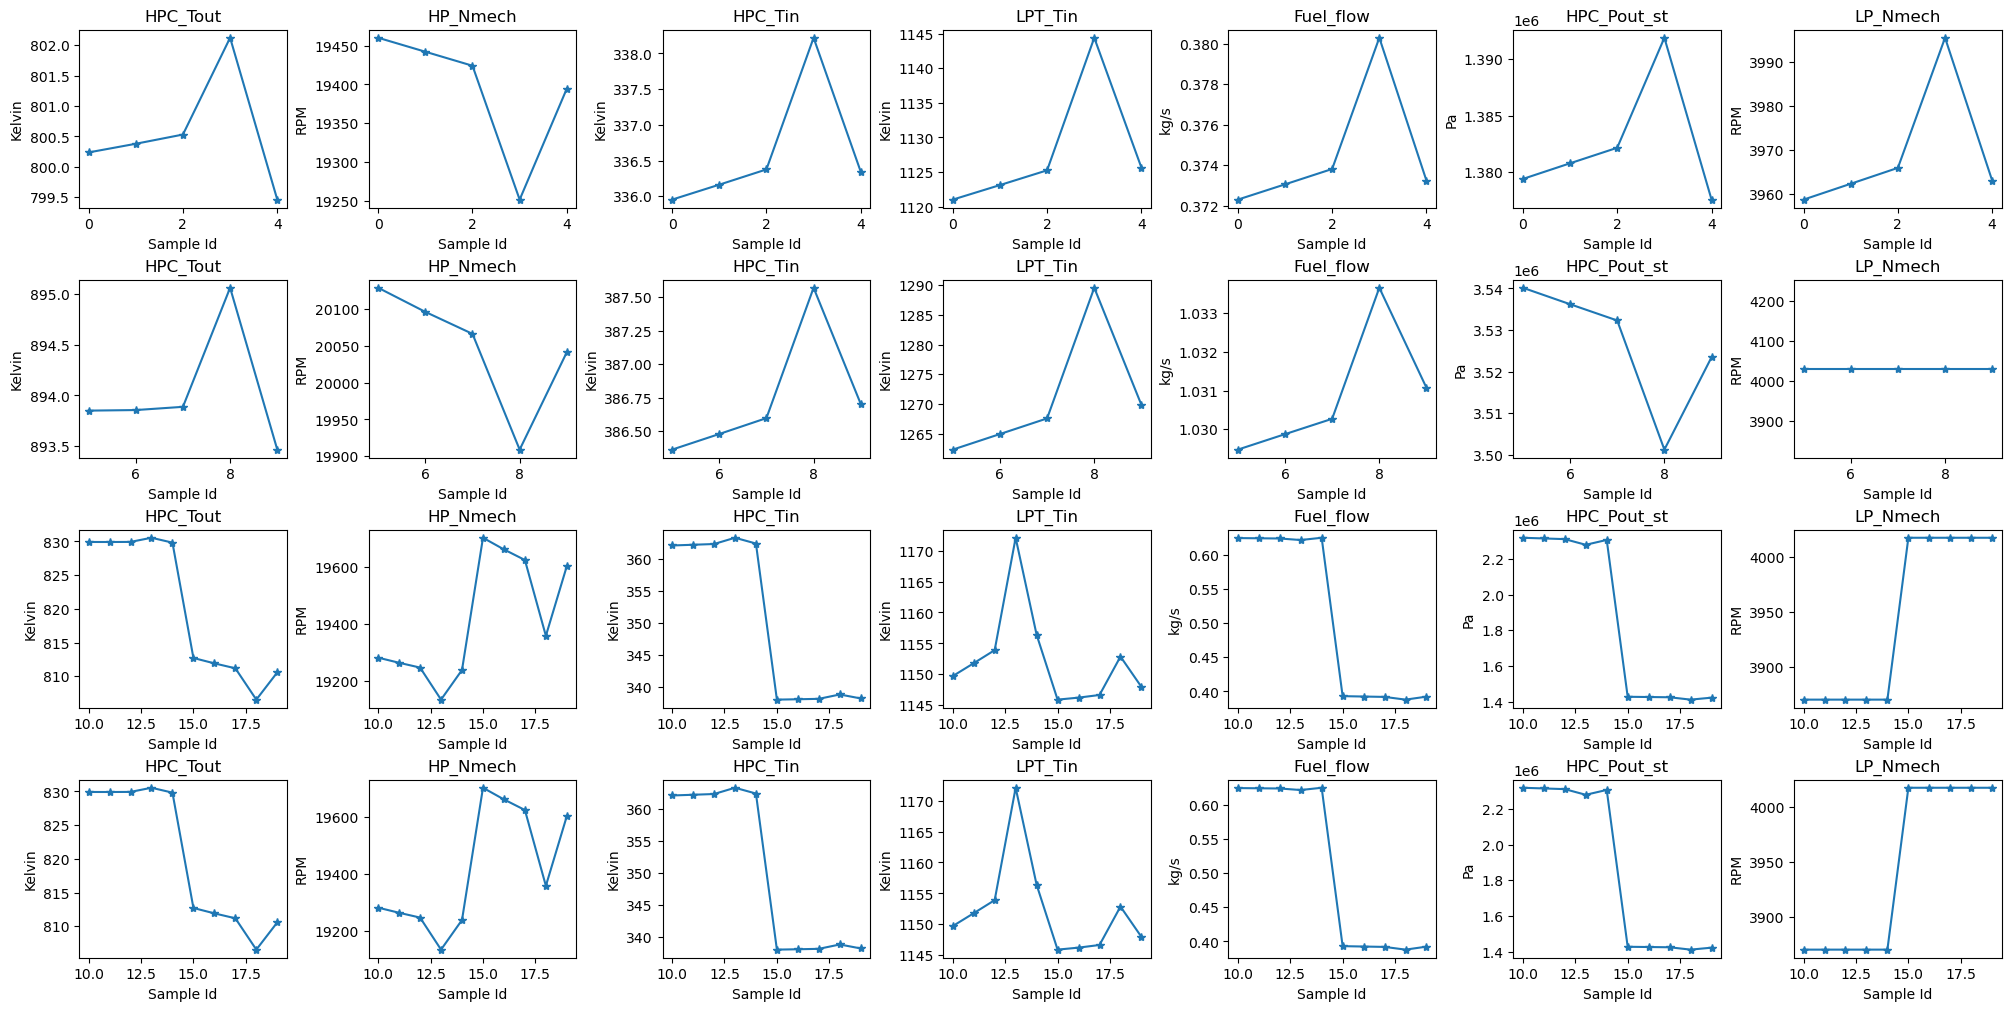

In [19]:
# We can extract measurements:
measurements = extract_info(all_info_df, list_variables_name=[s.name for s in list_sensors], context_name=True, phase_type=True, flight_conditions=False)

plt.figure(figsize=(20, 10), layout="constrained")
id_plot = 1
for context in list_context:
     for id_key, sensor in enumerate(list_sensors):
          phase_measurements = measurements[measurements['phase_type']==context.flight_condition.PHASE_TYPE]
          plt.subplot(len(list_context),  len(list_sensors), id_plot)
          id_plot += 1
          plt.plot(phase_measurements[sensor.name], '-*')
          plt.title(sensor.name)
          plt.xlabel('Sample Id')
          plt.ylabel(sensor.unit)